# Восканян Юрий, КИ22-17/2Б
## Практическая работа №3. Сверточные нейронные сети для решения задач сегментации

In [98]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models

### Подготовка данных

In [99]:
dataset_path = f'{os.getcwd()}/PH2 Dataset images'

In [100]:
dataset_path

'/home/ammrr/Рабочий стол/NN_3/PH2 Dataset images'

In [101]:
images = []
masks = []
IMG_SIZE = (256, 256)

In [102]:
for image in os.listdir(dataset_path):
    # read image and preprocessing 
    img = cv2.imread(f'{dataset_path}/{image}/{image}_Dermoscopic_Image/{image}.bmp')
    img = cv2.resize(img, IMG_SIZE)
    img = img / 255.0
    
    # mask 
    mask = cv2.imread(f'{dataset_path}/{image}/{image}_lesion/{image}_lesion.bmp', cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, IMG_SIZE)
    mask = mask / 255.0
    
    images.append(img)
    masks.append(mask)

In [103]:
X, y = np.array(images, dtype=np.float32), np.array(masks, dtype=np.float32)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

In [104]:
print(f"Размер тренировочной выборки: {len(X_train)}")
print(f"Размер валидационной выборки: {len(X_val)}")
print(f"Размер тестовой выборки: {len(X_test)}")

Размер тренировочной выборки: 120
Размер валидационной выборки: 40
Размер тестовой выборки: 40


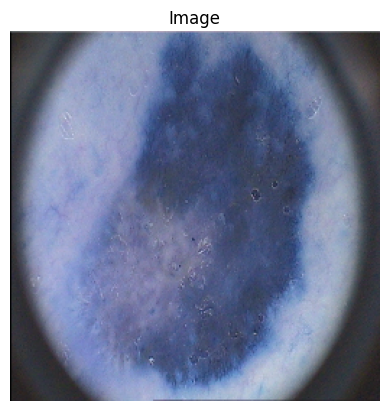

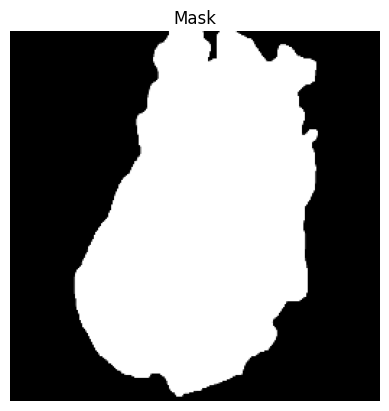

In [105]:
plt.imshow(X_train[0], cmap='gray')
plt.title('Image')
plt.axis('off')
plt.show()

plt.imshow(y_train[0], cmap='gray')
plt.title('Mask')
plt.axis('off')
plt.show()

In [106]:
def loss_graph(loss, val_loss, model):
    plt.figure(figsize=(10, 5))

    plt.plot(loss, label='Train Loss')
    plt.plot(val_loss, label='Validation Loss')

    test_loss, _ = model.evaluate(X_test, y_test)


    plt.axhline(y=test_loss, color='r', linestyle='--', label='Test Loss') 

    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('График ошибки (Loss)')
    plt.legend()
    plt.show()

def predict_image(y_pred_test):
    plt.figure(figsize=(10, 10))

    # Оригинальное изображение
    plt.imshow(y_test[0], cmap='gray')  # Это тестовое изображение
    plt.title('Original and Predicted Masks')
    plt.axis('off')

    # Наложить предсказание на оригинал с прозрачностью
    plt.imshow(y_pred_test[0], cmap='jet', alpha=0.5)  # Это предсказанное изображение с прозрачностью
    plt.axis('off')

    plt.show()

### Создание датасета

In [107]:
# Преобразуем массивы NumPy в tf.data.Dataset
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))

# Применяем shuffle, batch и prefetch для оптимизации
train_dataset = train_dataset.shuffle(buffer_size=1000).batch(8).prefetch(tf.data.experimental.AUTOTUNE)
val_dataset = val_dataset.batch(8).prefetch(tf.data.experimental.AUTOTUNE)
test_dataset = test_dataset.batch(8).prefetch(tf.data.experimental.AUTOTUNE)

### U Net

In [108]:
def unet_model(input_shape=(256, 256, 3)):
    inputs = layers.Input(shape=input_shape)

    # Сжимающие слои (Encoder)
    conv1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    conv1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(conv1)
    pool1 = layers.MaxPooling2D((2, 2))(conv1)

    conv2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(pool1)
    conv2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(conv2)
    pool2 = layers.MaxPooling2D((2, 2))(conv2)

    conv3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(pool2)
    conv3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(conv3)
    pool3 = layers.MaxPooling2D((2, 2))(conv3)

    conv4 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(pool3)
    conv4 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(conv4)
    pool4 = layers.MaxPooling2D((2, 2))(conv4)

    # Bottleneck
    conv5 = layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(pool4)
    conv5 = layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(conv5)

    # Расширяющие слои (Decoder) с пропусками (skip connections)
    up6 = layers.Conv2DTranspose(512, (2, 2), strides=(2, 2), padding='same')(conv5)
    merge6 = layers.concatenate([conv4, up6], axis=3)
    conv6 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(merge6)
    conv6 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(conv6)

    up7 = layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(conv6)
    merge7 = layers.concatenate([conv3, up7], axis=3)
    conv7 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(merge7)
    conv7 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(conv7)

    up8 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(conv7)
    merge8 = layers.concatenate([conv2, up8], axis=3)
    conv8 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(merge8)
    conv8 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(conv8)

    up9 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(conv8)
    merge9 = layers.concatenate([conv1, up9], axis=3)
    conv9 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(merge9)
    conv9 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(conv9)

    # Выходной слой
    output = layers.Conv2D(1, (1, 1), activation='sigmoid')(conv9)

    # Создаём модель
    model = models.Model(inputs=inputs, outputs=output)

    return model

In [109]:
model = unet_model()

model.compile(optimizer='adam', 
              loss='binary_crossentropy', 
              metrics=['accuracy'])

In [110]:
history = model.fit(
    train_dataset,
    batch_size=10,
    epochs=5,
    validation_data=val_dataset
)

Epoch 1/5


15/15 ━━━━━━━━━━━━━━━━━━━━ 112s 7s/step - accuracy: 0.6229 - loss: 0.6056 - val_accuracy: 0.7278 - val_loss: 0.6022
Epoch 2/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 105s 7s/step - accuracy: 0.7411 - loss: 0.5273 - val_accuracy: 0.8108 - val_loss: 0.4776
Epoch 3/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 105s 7s/step - accuracy: 0.8336 - loss: 0.4536 - val_accuracy: 0.8103 - val_loss: 0.4555
Epoch 4/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 108s 7s/step - accuracy: 0.8418 - loss: 0.4022 - val_accuracy: 0.7714 - val_loss: 0.5354
Epoch 5/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 115s 8s/step - accuracy: 0.8297 - loss: 0.3963 - val_accuracy: 0.8131 - val_loss: 0.4696


2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.7792 - loss: 0.4942


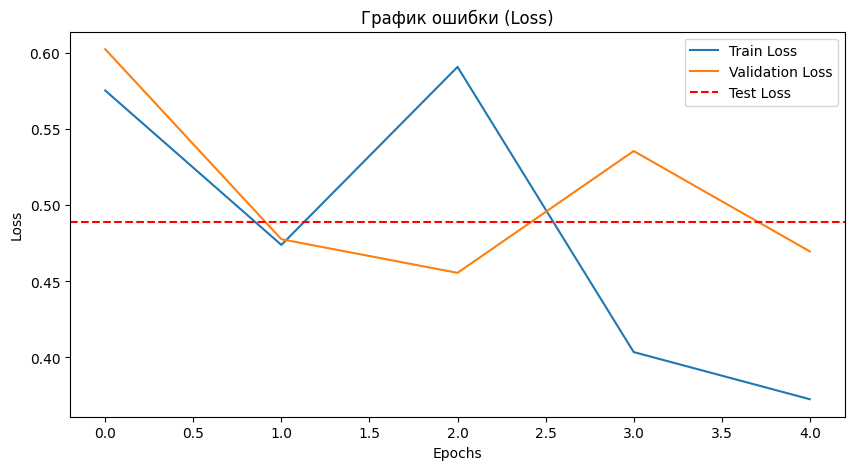

In [111]:
loss_graph(history.history['loss'], history.history['val_loss'], model)

In [112]:
y_pred_test = model.predict(X_test)
y_pred_test = y_pred_test.squeeze(axis=-1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step


In [ ]:
def iou_score(y_true, y_pred):
    # показывает, насколько сильно они перекрываются
    intersection = np.sum(y_true * y_pred)
    union = np.sum(y_true) + np.sum(y_pred) - intersection
    return intersection / union if union != 0 else 1.0


def dice_score(y_true, y_pred, smooth=1e-6):
    # очень похож на IoU, но чуть по-другому считает баланс между precision и recall.
    intersection = np.sum(y_true * y_pred)
    return (2. * intersection + smooth) / (np.sum(y_true) + np.sum(y_pred) + smooth)

In [114]:
ious = [iou_score(y_true, y_pred) for y_true, y_pred in zip(y_test, y_pred_test)]
dices = [dice_score(y_true, y_pred) for y_true, y_pred in zip(y_test, y_pred_test)]

In [115]:
iou_score_test = np.mean(ious)
dice_score_test = np.mean(dices)

In [116]:
print(f'{iou_score_test = }')
print(f'{dice_score_test = }')

iou_score_test = np.float32(0.39585766)
dice_score_test = np.float32(0.55100536)


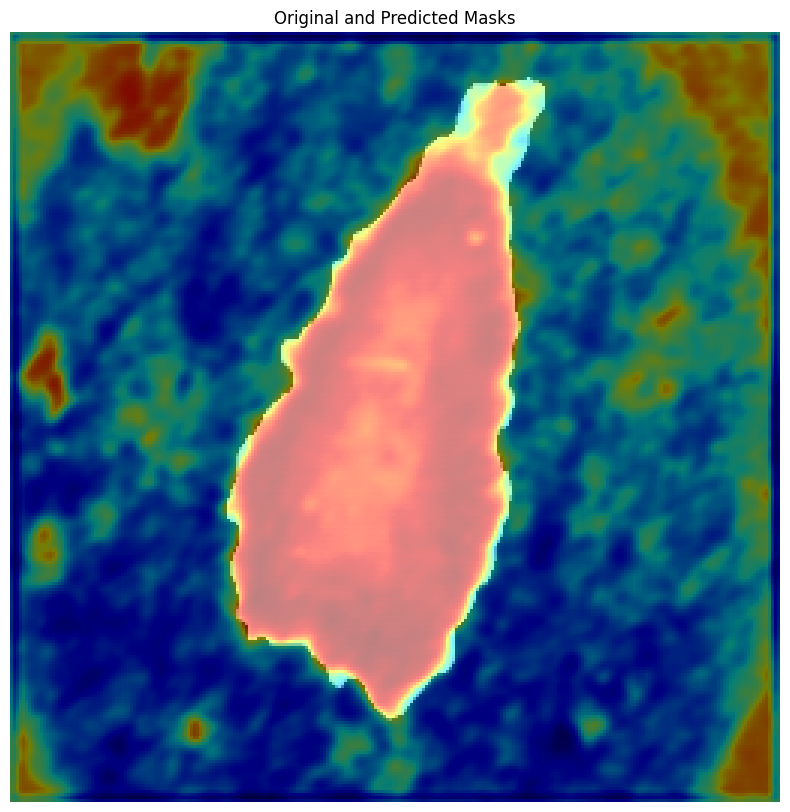

In [117]:
predict_image(y_pred_test)

# SegNet

In [118]:
def simple_segnet(input_shape=(256, 256, 3)):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(inputs)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Bottleneck
    x = layers.Conv2D(256, (3, 3), padding='same', activation='relu')(x)
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)

    # Decoder
    x = layers.Conv2DTranspose(64, (2, 2), strides=2, padding='same', activation='relu')(x)
    x = layers.Conv2DTranspose(1, (2, 2), strides=2, padding='same', activation=None)(x)

    outputs = layers.Activation('sigmoid')(x)

    model = models.Model(inputs=inputs, outputs=outputs)
    return model

In [119]:
model = simple_segnet()

model.compile(optimizer='adam', 
              loss='binary_crossentropy', 
              metrics=['accuracy'])

In [120]:
history = model.fit(
    train_dataset,
    batch_size=10,
    epochs=10,
    validation_data=val_dataset
)

Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 13s 766ms/step - accuracy: 0.6302 - loss: 0.6420 - val_accuracy: 0.6414 - val_loss: 0.6308
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 768ms/step - accuracy: 0.6988 - loss: 0.5192 - val_accuracy: 0.6688 - val_loss: 0.5708
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 770ms/step - accuracy: 0.7543 - loss: 0.4661 - val_accuracy: 0.7653 - val_loss: 0.5160
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 20s 747ms/step - accuracy: 0.8240 - loss: 0.3996 - val_accuracy: 0.8076 - val_loss: 0.4768
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 743ms/step - accuracy: 0.8579 - loss: 0.3319 - val_accuracy: 0.8413 - val_loss: 0.3705
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 21s 747ms/step - accuracy: 0.8680 - loss: 0.3174 - val_accuracy: 0.8540 - val_loss: 0.3571
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 755ms/step - accuracy: 0.8643 - loss: 0.3121 - val_accuracy: 0.8669 - val_loss: 0.3313
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 744ms/step - accuracy: 0.8691 - loss: 0.2950 - val_accu

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 209ms/step - accuracy: 0.8159 - loss: 0.4473


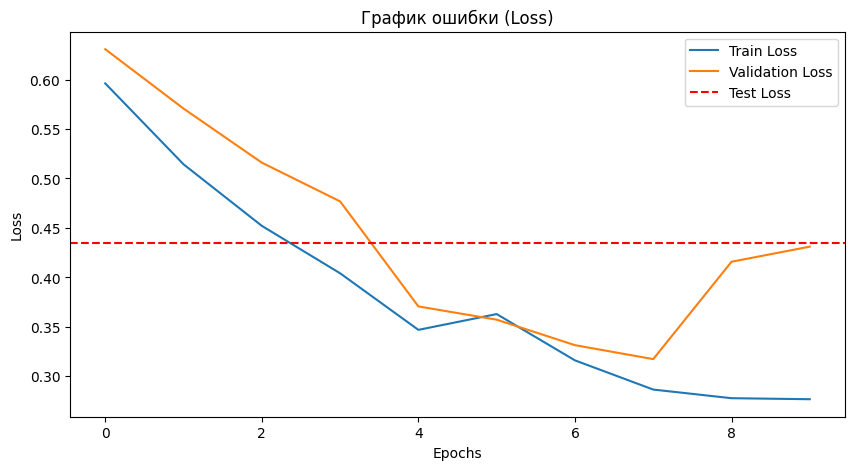

In [121]:
loss_graph(history.history['loss'], history.history['val_loss'], model)

In [122]:
y_pred_test = model.predict(X_test)
y_pred_test = y_pred_test.squeeze(axis=-1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 235ms/step


In [123]:
ious = [iou_score(y_true, y_pred) for y_true, y_pred in zip(y_test, y_pred_test)]
dices = [dice_score(y_true, y_pred) for y_true, y_pred in zip(y_test, y_pred_test)]

In [124]:
iou_score_test = np.mean(ious)
dice_score_test = np.mean(dices)

In [125]:
print(f'{iou_score_test = }')
print(f'{dice_score_test = }')

iou_score_test = np.float32(0.49549466)
dice_score_test = np.float32(0.6454468)


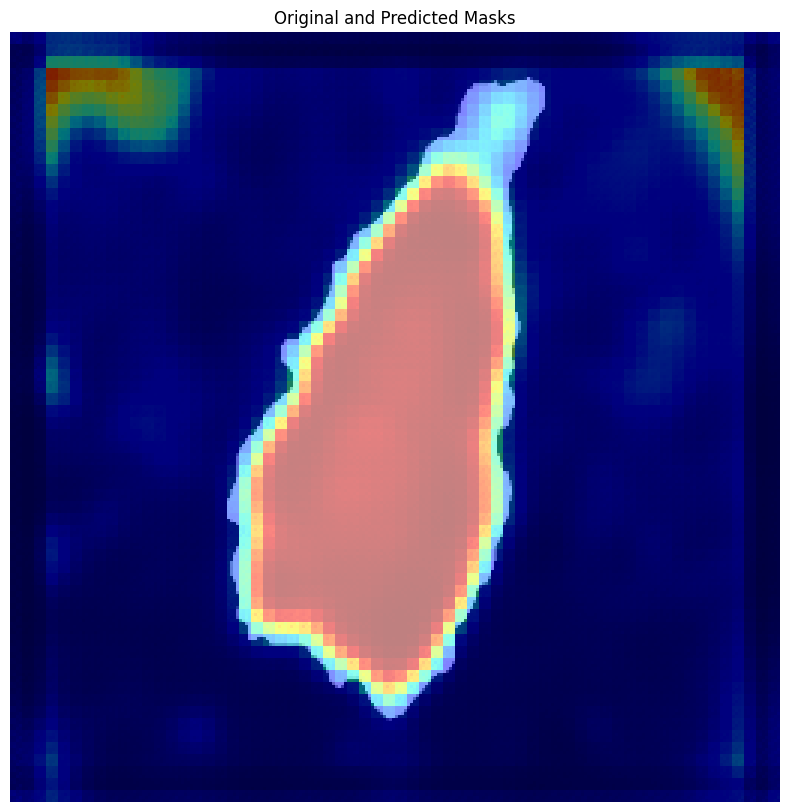

In [126]:
predict_image(y_pred_test)

### ExtendedUNet

In [127]:
def double_conv(x, filters):
    x = layers.Conv2D(filters, (3, 3), padding='same', activation='relu')(x)
    x = layers.Conv2D(filters, (3, 3), padding='same', activation='relu')(x)
    return x

def extended_unet(input_shape=(256, 256, 3)):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    conv1 = double_conv(inputs, 32)
    pool1 = layers.MaxPooling2D((2, 2))(conv1)

    conv2 = double_conv(pool1, 64)
    pool2 = layers.MaxPooling2D((2, 2))(conv2)

    conv3 = double_conv(pool2, 128)
    pool3 = layers.MaxPooling2D((2, 2))(conv3)

    conv4 = double_conv(pool3, 256)
    pool4 = layers.MaxPooling2D((2, 2))(conv4)

    # Bottleneck
    bottleneck = double_conv(pool4, 512)

    # Decoder
    up4 = layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(bottleneck)
    concat4 = layers.Concatenate()([up4, conv4])
    dec4 = double_conv(concat4, 256)

    up3 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(dec4)
    concat3 = layers.Concatenate()([up3, conv3])
    dec3 = double_conv(concat3, 128)

    up2 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(dec3)
    concat2 = layers.Concatenate()([up2, conv2])
    dec2 = double_conv(concat2, 64)

    up1 = layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(dec2)
    concat1 = layers.Concatenate()([up1, conv1])
    dec1 = double_conv(concat1, 32)

    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(dec1)

    model = models.Model(inputs, outputs)
    return model

In [128]:
model = extended_unet()

model.compile(optimizer='adam', 
              loss='binary_crossentropy', 
              metrics=['accuracy'])

In [129]:
history = model.fit(
    train_dataset,
    batch_size=10,
    epochs=10,
    validation_data=val_dataset
)

Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 44s 3s/step - accuracy: 0.5812 - loss: 0.6758 - val_accuracy: 0.6414 - val_loss: 0.6243
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step - accuracy: 0.6902 - loss: 0.5767 - val_accuracy: 0.6414 - val_loss: 0.5729
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step - accuracy: 0.7200 - loss: 0.4532 - val_accuracy: 0.6685 - val_loss: 0.5861
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.8248 - loss: 0.4034 - val_accuracy: 0.7757 - val_loss: 0.5284
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step - accuracy: 0.8459 - loss: 0.3755 - val_accuracy: 0.8463 - val_loss: 0.3783
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 42s 3s/step - accuracy: 0.8441 - loss: 0.3855 - val_accuracy: 0.8530 - val_loss: 0.3597
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.8538 - loss: 0.3451 - val_accuracy: 0.7950 - val_loss: 0.4656
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step - accuracy: 0.8393 - loss: 0.3647 - val_accuracy: 0.8470 - val_loss:

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 508ms/step - accuracy: 0.8030 - loss: 0.4660


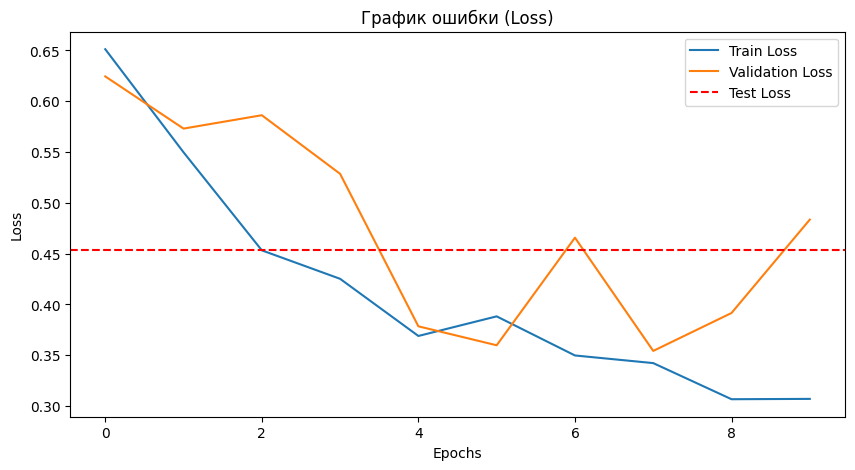

In [130]:
loss_graph(history.history['loss'], history.history['val_loss'], model)

In [131]:
y_pred_test = model.predict(X_test)
y_pred_test = y_pred_test.squeeze(axis=-1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 670ms/step


In [132]:
ious = [iou_score(y_true, y_pred) for y_true, y_pred in zip(y_test, y_pred_test)]
dices = [dice_score(y_true, y_pred) for y_true, y_pred in zip(y_test, y_pred_test)]

In [133]:
iou_score_test = np.mean(ious)
dice_score_test = np.mean(dices)

In [134]:
print(f'{iou_score_test = }')
print(f'{dice_score_test = }')

iou_score_test = np.float32(0.485511)
dice_score_test = np.float32(0.63936174)


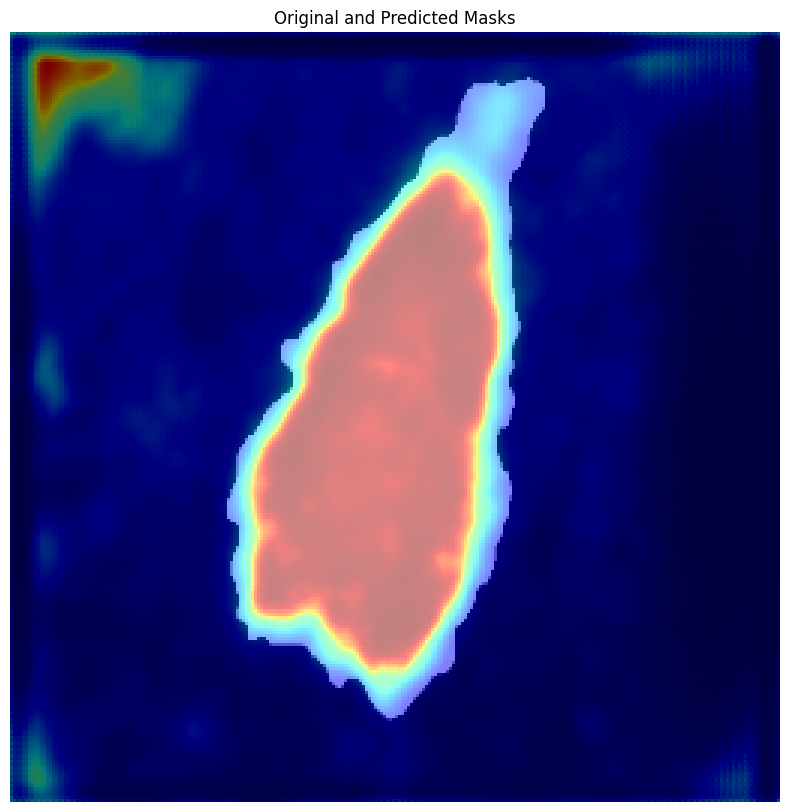

In [135]:
predict_image(y_pred_test)